# Inovegen Internship - Task 3: Customer Churn Prediction

## Project objective

This project builds a supervised machine-learning solution to predict whether a telecommunications customer will leave the company (**Churn = Yes**). It combines the data-cleaning and EDA skills from Task 1 with the classification and evaluation skills from Task 2.

## Dataset

**IBM Telco Customer Churn dataset**

- 7,043 customer records
- 20 predictor columns plus the target `Churn`
- Customer demographics, subscribed services, contract details, tenure and charges
- Source repository: https://github.com/IBM/telco-customer-churn-on-icp4d
- CSV source: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

The notebook first looks for `Telco_Customer_Churn.csv` in the working folder. If it is absent, it downloads the same public file from IBM's repository. This makes the notebook work in Jupyter, Google Colab and GitHub-based workflows.

## Workflow

1. Load and inspect the dataset
2. Handle missing values, duplicates and unsuitable columns
3. Perform exploratory data analysis (EDA)
4. Encode categorical features and split the data
5. Train a baseline and two classification models
6. Evaluate accuracy, precision, recall, F1-score, ROC-AUC and confusion matrix
7. Interpret findings, limitations and improvements


In [1]:
# 1. Import libraries and set reproducibility options
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42
pd.set_option('display.max_columns', 30)
print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load and understand the data

The prediction target is `Churn`: **1 means the customer left** and **0 means the customer stayed**. The raw labels are initially `Yes` and `No` and are encoded later.

In [2]:
DATA_PATH = Path('Telco_Customer_Churn.csv')
DATA_URL = ('https://raw.githubusercontent.com/IBM/'
            'telco-customer-churn-on-icp4d/master/data/'
            'Telco-Customer-Churn.csv')

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    source_used = f'Local file: {DATA_PATH}'
else:
    df = pd.read_csv(DATA_URL)
    source_used = 'IBM public repository URL'

print(f'Source used: {source_used}')
print(f'Raw dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.head())

Source used: IBM public repository URL
Raw dataset shape: 7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print('Column data types:')
display(df.dtypes.rename('data_type').to_frame())

print('Raw target counts:')
display(df['Churn'].value_counts(dropna=False).rename('count').to_frame())

Column data types:


,data_type
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Raw target counts:


,count
Churn,
No,5174
Yes,1869


## 2. Data quality checks and preprocessing

The following issues are checked before modelling:

- missing or blank values;
- exact duplicate rows;
- invalid target values;
- columns that should be numeric but were imported as text;
- identifier columns that do not describe customer behaviour.

`customerID` is unsuitable for prediction because it is a unique identifier. Learning patterns from arbitrary IDs would not generalize to future customers.

In [4]:
# TotalCharges appears as object because blank strings are present.
blank_total_charges = df['TotalCharges'].astype(str).str.strip().eq('').sum()
duplicate_rows = df.duplicated().sum()
duplicate_ids = df['customerID'].duplicated().sum()
missing_before_conversion = df.isna().sum().sum()
unexpected_targets = (~df['Churn'].isin(['Yes', 'No'])).sum()

quality_report = pd.DataFrame({
    'Check': [
        'Blank TotalCharges values',
        'Missing values before conversion',
        'Exact duplicate rows',
        'Duplicate customer IDs',
        'Unexpected target labels'
    ],
    'Count': [
        blank_total_charges,
        missing_before_conversion,
        duplicate_rows,
        duplicate_ids,
        unexpected_targets
    ]
})
display(quality_report)

,Check,Count
0,Blank TotalCharges values,11
1,Missing values before conversion,0
2,Exact duplicate rows,0
3,Duplicate customer IDs,0
4,Unexpected target labels,0


In [5]:
# Convert TotalCharges to numeric; blank strings become NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_by_column = df.isna().sum()
missing_by_column = missing_by_column[missing_by_column > 0].sort_values(ascending=False)
print('Missing values after numeric conversion:')
display(missing_by_column.rename('missing_count').to_frame())

# Only 11 of 7,043 rows are incomplete (about 0.16%), so dropping them has
# negligible impact and avoids inventing historical charges for new customers.
rows_before = len(df)
df = df.dropna(subset=['TotalCharges']).drop_duplicates().reset_index(drop=True)

print(f'Rows removed: {rows_before - len(df)}')
print(f'Cleaned dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Remaining missing values: {df.isna().sum().sum()}')
print(f'Remaining duplicate rows: {df.duplicated().sum()}')

Missing values after numeric conversion:


,missing_count
TotalCharges,11


Rows removed: 11
Cleaned dataset shape: 7,032 rows x 21 columns
Remaining missing values: 0
Remaining duplicate rows: 0


## 3. Exploratory data analysis

EDA is used to understand class balance and identify customer characteristics associated with churn. Associations are descriptive and do not prove causation.

### Visualization 1 - Churn distribution

This chart checks whether the target is balanced. A majority-class baseline and stratified splitting are used because non-churn customers are more common.

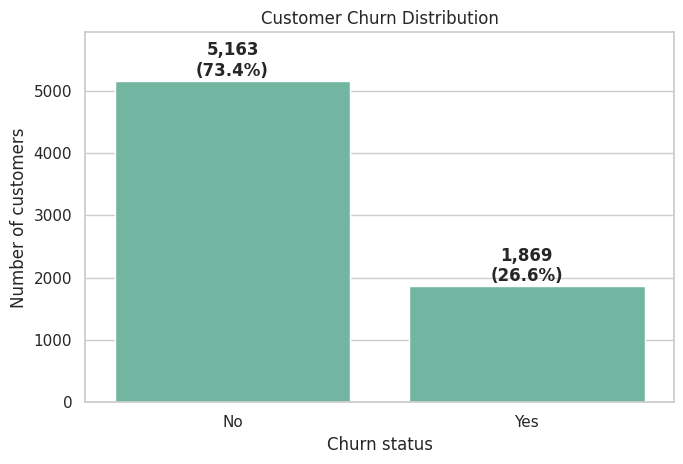

,Customers,Percentage
Churn,,
No,5163,73.4
Yes,1869,26.6


In [6]:
churn_counts = df['Churn'].value_counts().reindex(['No', 'Yes'])
churn_rates = (churn_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4.8))
sns.countplot(data=df, x='Churn', order=['No', 'Yes'], ax=ax)
ax.set_title('Customer Churn Distribution')
ax.set_xlabel('Churn status')
ax.set_ylabel('Number of customers')
for index, count in enumerate(churn_counts):
    ax.text(index, count + 70, f'{count:,}\n({churn_rates.iloc[index]}%)',
            ha='center', fontweight='bold')
ax.set_ylim(0, churn_counts.max() * 1.15)
plt.tight_layout()
plt.show()

display(pd.DataFrame({'Customers': churn_counts, 'Percentage': churn_rates}))

### Visualization 2 - Churn rate by contract type

Contract type is important because longer commitments may be associated with greater retention.

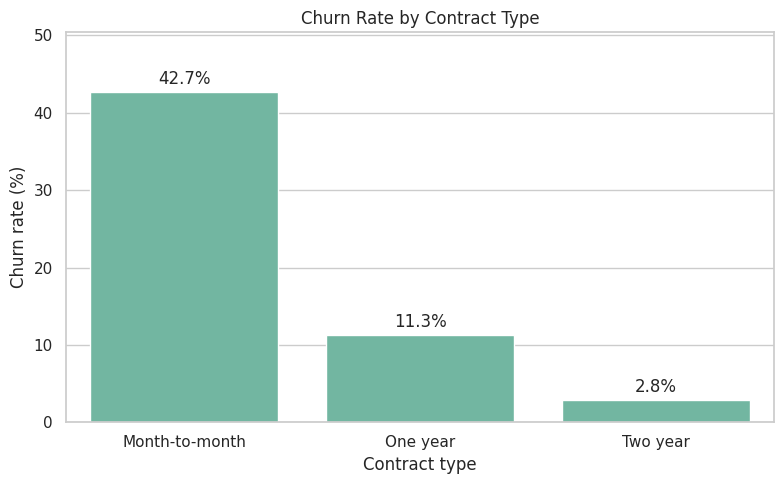

,Churn rate (%),Customers
Contract,,
Month-to-month,42.71,3875
One year,11.28,1472
Two year,2.85,1685


In [7]:
contract_churn = (
    df.assign(ChurnFlag=(df['Churn'] == 'Yes').astype(int))
      .groupby('Contract', observed=False)['ChurnFlag']
      .agg(['mean', 'count'])
      .sort_values('mean', ascending=False)
)
contract_churn['mean'] *= 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=contract_churn.index, y=contract_churn['mean'], ax=ax)
ax.set_title('Churn Rate by Contract Type')
ax.set_xlabel('Contract type')
ax.set_ylabel('Churn rate (%)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
ax.set_ylim(0, contract_churn['mean'].max() * 1.18)
plt.tight_layout()
plt.show()

display(contract_churn.rename(columns={'mean': 'Churn rate (%)', 'count': 'Customers'}).round(2))

### Visualization 3 - Monthly charges by churn status

The distribution shows whether customers who leave tend to have different monthly costs from customers who remain.

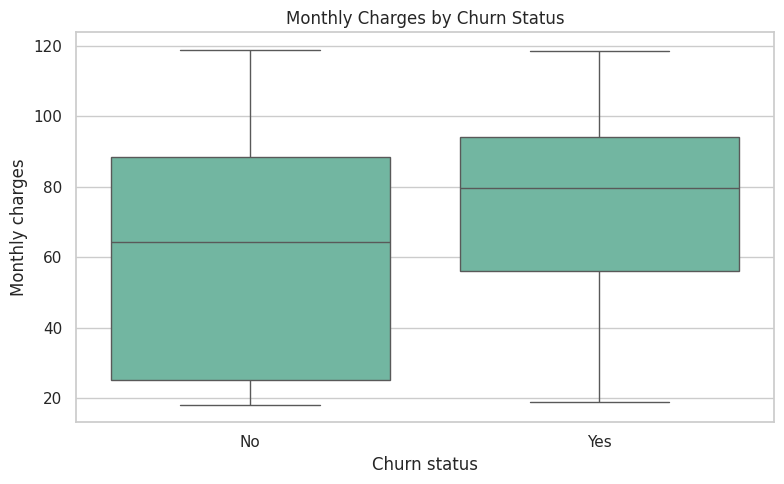

,count,mean,median,std
Churn,,,,
No,5163,61.31,64.45,31.09
Yes,1869,74.44,79.65,24.67


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', order=['No', 'Yes'], ax=ax)
ax.set_title('Monthly Charges by Churn Status')
ax.set_xlabel('Churn status')
ax.set_ylabel('Monthly charges')
plt.tight_layout()
plt.show()

monthly_summary = df.groupby('Churn')['MonthlyCharges'].agg(['count', 'mean', 'median', 'std'])
display(monthly_summary.round(2))

### Visualization 4 - Churn rate by tenure group

Tenure is grouped only for interpretation. The model receives the original numeric `tenure` feature.

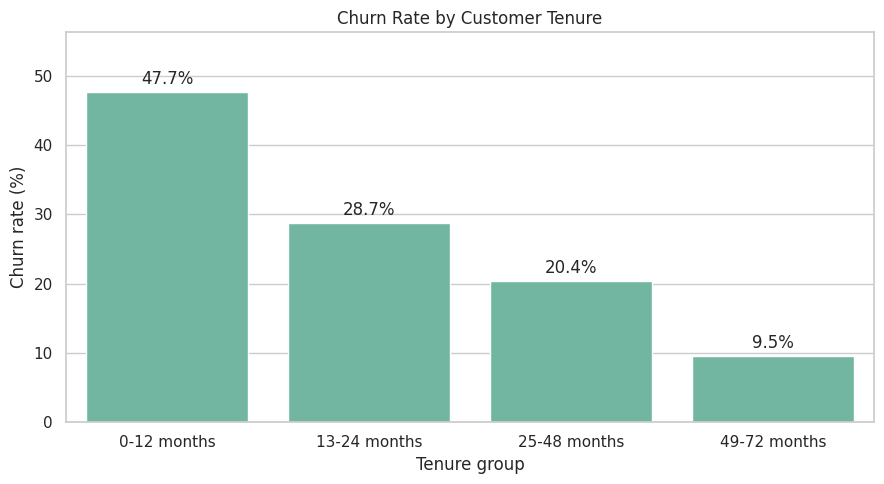

,Churn rate (%),Customers
TenureGroup,,
0-12 months,47.68,2175
13-24 months,28.71,1024
25-48 months,20.39,1594
49-72 months,9.51,2239


In [9]:
tenure_order = ['0-12 months', '13-24 months', '25-48 months', '49-72 months']
df['TenureGroup'] = pd.cut(
    df['tenure'], bins=[-1, 12, 24, 48, 72], labels=tenure_order
)

tenure_churn = (
    df.assign(ChurnFlag=(df['Churn'] == 'Yes').astype(int))
      .groupby('TenureGroup', observed=False)['ChurnFlag']
      .agg(['mean', 'count'])
      .reindex(tenure_order)
)
tenure_churn['mean'] *= 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=tenure_churn.index, y=tenure_churn['mean'], ax=ax)
ax.set_title('Churn Rate by Customer Tenure')
ax.set_xlabel('Tenure group')
ax.set_ylabel('Churn rate (%)')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
ax.set_ylim(0, tenure_churn['mean'].max() * 1.18)
plt.tight_layout()
plt.show()

display(tenure_churn.rename(columns={'mean': 'Churn rate (%)', 'count': 'Customers'}).round(2))

## 4. Prepare features and target

Preparation decisions:

- `Churn` is encoded as 1 for Yes and 0 for No.
- `customerID` is removed because it is a unique identifier.
- `TenureGroup` is removed because it was created only for EDA and duplicates information already contained in numeric `tenure`.
- Numeric features are median-imputed and standardized inside the modelling pipeline.
- Categorical features are most-frequent-imputed and one-hot encoded with unknown-category protection.
- An 80/20 stratified split preserves the churn proportion in both sets.

Using a pipeline ensures preprocessing is learned only from the training data and prevents leakage from the test set.

In [10]:
X = df.drop(columns=['Churn', 'customerID', 'TenureGroup'])
y = df['Churn'].map({'No': 0, 'Yes': 1})

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f'Predictor columns: {X.shape[1]}')
print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'Target values: {sorted(y.unique())}')

Predictor columns: 19
Numeric features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Target values: [np.int64(0), np.int64(1)]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

split_summary = pd.DataFrame({
    'Split': ['Training', 'Testing'],
    'Rows': [len(X_train), len(X_test)],
    'Churn rate (%)': [y_train.mean() * 100, y_test.mean() * 100]
})
display(split_summary.round(2))

,Split,Rows,Churn rate (%)
0,Training,5625,26.58
1,Testing,1407,26.58


In [12]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])

models = {
    'Dummy Baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(
        max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    )
}

pipelines = {
    name: Pipeline([('preprocessor', preprocessor), ('model', model)])
    for name, model in models.items()
}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f'{name} trained successfully.')

Dummy Baseline trained successfully.
Logistic Regression trained successfully.
Random Forest trained successfully.


## 5. Model evaluation

The positive class is **churn (1)**.

- **Accuracy:** percentage of all predictions that are correct.
- **Precision:** among customers predicted to churn, the percentage that actually churned.
- **Recall:** among customers who actually churned, the percentage detected by the model.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** ability to rank churners above non-churners across probability thresholds; 0.5 is random and 1.0 is perfect.

In churn management, recall is important because a false negative is a customer who leaves without being identified for retention action. Precision also matters because contacting too many low-risk customers wastes resources.

In [13]:
results = []
predictions = {}
probabilities = {}

for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_prob
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = (
    pd.DataFrame(results)
      .set_index('Model')
      .sort_values('F1-score', ascending=False)
)
display(results_df.round(3))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.726,0.49,0.797,0.607,0.835
Random Forest,0.775,0.57,0.628,0.598,0.825
Dummy Baseline,0.734,0.00,0.000,0.000,0.500


### Model comparison visualization

The baseline reveals why accuracy alone can be misleading: predicting that every customer stays can achieve a reasonable-looking accuracy but detects no churners.

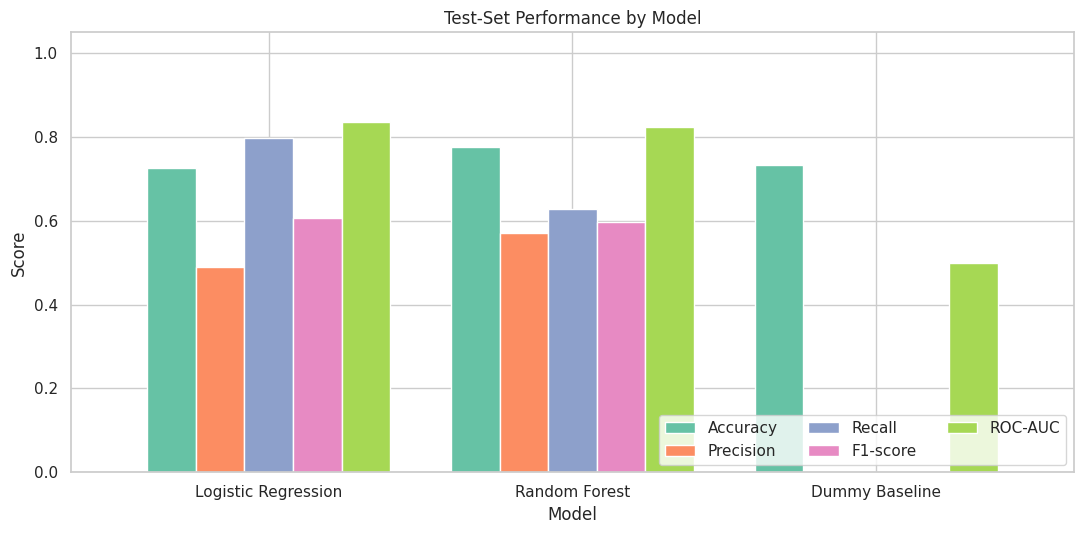

In [14]:
ax = results_df.plot(kind='bar', figsize=(11, 5.5), ylim=(0, 1.05), width=0.8)
ax.set_title('Test-Set Performance by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.legend(loc='lower right', ncol=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Confusion matrices

Rows show actual classes and columns show predicted classes. For churn prediction:

- **True negative:** correctly predicted to stay.
- **False positive:** predicted to churn but stayed.
- **False negative:** predicted to stay but churned.
- **True positive:** correctly predicted to churn.

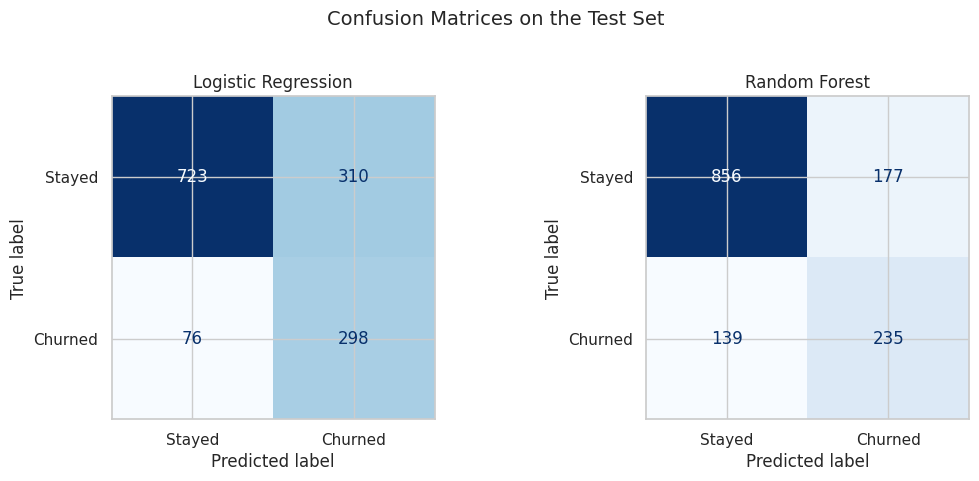


Logistic Regression classification report:
              precision    recall  f1-score   support

      Stayed      0.905     0.700     0.789      1033
     Churned      0.490     0.797     0.607       374

    accuracy                          0.726      1407
   macro avg      0.698     0.748     0.698      1407
weighted avg      0.795     0.726     0.741      1407


Random Forest classification report:
              precision    recall  f1-score   support

      Stayed      0.860     0.829     0.844      1033
     Churned      0.570     0.628     0.598       374

    accuracy                          0.775      1407
   macro avg      0.715     0.728     0.721      1407
weighted avg      0.783     0.775     0.779      1407



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
for ax, name in zip(axes, ['Logistic Regression', 'Random Forest']):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        display_labels=['Stayed', 'Churned'],
        cmap='Blues',
        colorbar=False,
        ax=ax
    )
    ax.set_title(name)
fig.suptitle('Confusion Matrices on the Test Set', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

for name in ['Logistic Regression', 'Random Forest']:
    print(f'\n{name} classification report:')
    print(classification_report(
        y_test, predictions[name],
        target_names=['Stayed', 'Churned'], digits=3
    ))

### ROC curves

Curves closer to the upper-left corner indicate better separation between customers who churn and customers who stay.

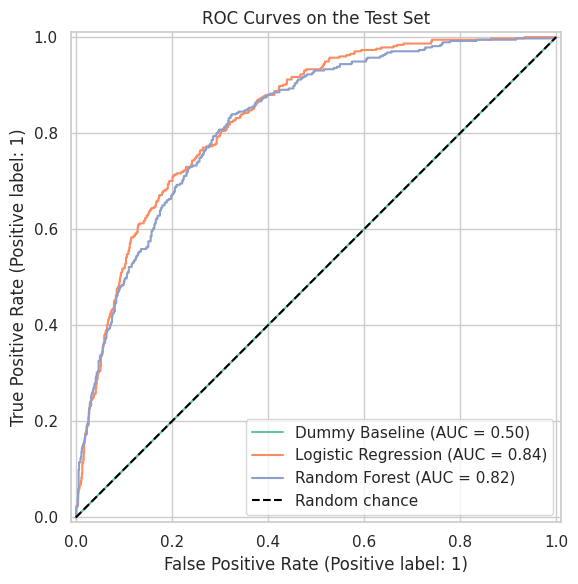

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in pipelines:
    RocCurveDisplay.from_predictions(
        y_test, probabilities[name], name=name, ax=ax
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random chance')
ax.set_title('ROC Curves on the Test Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Cross-validation

Five-fold stratified cross-validation checks whether model performance is stable across multiple validation subsets instead of depending entirely on one test split.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name in ['Logistic Regression', 'Random Forest']:
    scores = cross_val_score(
        pipelines[name], X_train, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    cv_results.append({
        'Model': name,
        'Mean CV ROC-AUC': scores.mean(),
        'Standard deviation': scores.std(),
        'Fold scores': np.round(scores, 3)
    })

cv_df = pd.DataFrame(cv_results).set_index('Model')
display(cv_df)

,Mean CV ROC-AUC,Standard deviation,Fold scores
Model,,,
Logistic Regression,0.845938,0.005372,"[0.847, 0.843, 0.837, 0.85, 0.853]"
Random Forest,0.840700,0.006100,"[0.839, 0.83, 0.841, 0.845, 0.848]"


## 7. Interpreting the Logistic Regression model

The chart shows the strongest positive and negative coefficients after preprocessing. Positive coefficients increase the model's estimated likelihood of churn; negative coefficients reduce it. Coefficients show associations within this model and do not prove that a feature causes churn.

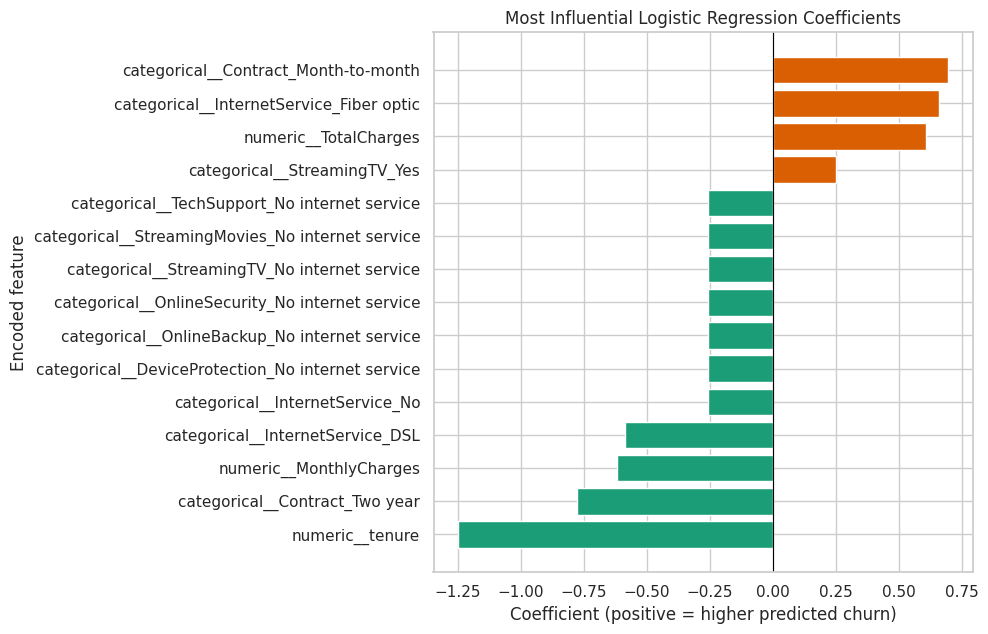

,Feature,Coefficient
36,categorical__Contract_Month-to-month,0.696
16,categorical__InternetService_Fiber optic,0.661
3,numeric__TotalCharges,0.607
32,categorical__StreamingTV_Yes,0.252
22,categorical__OnlineBackup_No internet service,-0.257
25,categorical__DeviceProtection_No internet service,-0.257
17,categorical__InternetService_No,-0.257
28,categorical__TechSupport_No internet service,-0.257
34,categorical__StreamingMovies_No internet service,-0.257
31,categorical__StreamingTV_No internet service,-0.257


In [18]:
logistic_pipeline = pipelines['Logistic Regression']
feature_names = logistic_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = logistic_pipeline.named_steps['model'].coef_[0]

coefficient_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coefficient_df['Absolute coefficient'] = coefficient_df['Coefficient'].abs()
top_coefficients = coefficient_df.nlargest(15, 'Absolute coefficient').sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 6.5))
colors = ['#d95f02' if value > 0 else '#1b9e77' for value in top_coefficients['Coefficient']]
ax.barh(top_coefficients['Feature'], top_coefficients['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Most Influential Logistic Regression Coefficients')
ax.set_xlabel('Coefficient (positive = higher predicted churn)')
ax.set_ylabel('Encoded feature')
plt.tight_layout()
plt.show()

display(top_coefficients[['Feature', 'Coefficient']].sort_values('Coefficient', ascending=False).round(3))

## 8. Main findings and conclusion

In the verified test run, **Logistic Regression achieved 72.6% accuracy, 49.0% precision, 79.7% churn recall, 60.7% F1-score and 83.5% ROC-AUC**. Random Forest achieved **77.5% accuracy, 57.0% precision, 62.8% churn recall, 59.8% F1-score and 82.5% ROC-AUC**. The Dummy baseline had 73.4% accuracy but **0% churn recall and 0% F1-score**, demonstrating why accuracy alone is misleading. The analysis supports the following conclusions:

1. Churn is imbalanced: only about one quarter of customers churn, so accuracy must be interpreted with precision, recall, F1-score and ROC-AUC.
2. Month-to-month customers have a much higher churn rate than customers with one-year or two-year contracts.
3. Customers who churn generally have higher monthly charges.
4. Churn is highest among customers in their first year and declines as tenure increases.
5. Both trained models provide much more useful churn detection than the majority-class baseline.
6. The final model should be selected using recall, F1-score, ROC-AUC, cross-validation stability and the business cost of retention contacts—not accuracy alone.

For a practical retention campaign, Logistic Regression is a strong choice when interpretability and churn recall are priorities. Random Forest offers a nonlinear alternative. Before deployment, the company should choose a probability threshold based on the relative cost of missing a churner versus contacting a customer who would have stayed.

## 9. Limitations

- The dataset is a public sample and may not represent a specific current telecom business.
- It provides one snapshot and does not include time-series changes in customer behaviour.
- No external dataset was available for independent validation.
- Class weighting and the default 0.5 threshold may not match the company's real retention budget.
- Coefficients describe statistical associations, not causal effects.
- Customer value and the cost or success of retention offers are not included.

## 10. Possible improvements

- Tune hyperparameters with nested cross-validation.
- Select the probability threshold using retention costs and customer lifetime value.
- Evaluate calibrated probabilities and precision-recall curves.
- Compare gradient boosting models.
- Add recent usage, service complaints, support interactions and payment failures.
- Validate on newer customers and monitor performance and fairness after deployment.

## Reproducibility

The notebook uses a fixed random seed (`42`), stratified splitting and preprocessing pipelines. Run all cells from top to bottom. Keep `Telco_Customer_Churn.csv` beside the notebook, or allow the notebook to load the same file from IBM's public repository.
